# 🌐 Malicious URL Detection Analysis
> **Domain:** Cyber Security & Web Safety  
> **Task:** Identifying malicious web links using structural and statistical features.

## Environment & Data Setup
In this phase, we initialize our analysis environment and load the pre-processed URL dataset. This dataset typically contains features like URL length, count of special characters, presence of sensitive keywords, and domain-related metrics.

### 🧪 Key Techniques:
* **Information Theory:** Using `entropy` and `mutual_info_classif` to measure the uncertainty and predictive power of URL features.
* **Visualization:** Leveraging `fivethirtyeight` styling for clear, publication-quality plots.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif


# Set up the style for the plots
plt.style.use('fivethirtyeight')
sns.set_palette("husl")
%matplotlib inline

# Load the CSV file
df = pd.read_csv('../data/processed_malicious_url.csv')

--- GENERAL INFORMATION ---
<class 'pandas.DataFrame'>
RangeIndex: 646117 entries, 0 to 646116
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   url                 646117 non-null  str    
 1   target              646117 non-null  str    
 2   url_len             646117 non-null  int64  
 3   hostname_len        646117 non-null  int64  
 4   dot_count           646117 non-null  int64  
 5   dash_count          646117 non-null  int64  
 6   digit_ratio         646117 non-null  float64
 7   entropy             646117 non-null  float64
 8   is_trash_tld        646117 non-null  int64  
 9   is_popular_tld      646117 non-null  int64  
 10  has_ip              646117 non-null  int64  
 11  is_exec             646117 non-null  int64  
 12  keyword_count       646117 non-null  int64  
 13  subdomain_count     646117 non-null  int64  
 14  special_ratio       646117 non-null  float64
 15  has_number_in_hos

,url_len,hostname_len,dot_count,dash_count,digit_ratio,entropy,is_trash_tld,is_popular_tld,has_ip,is_exec,keyword_count,subdomain_count,special_ratio,has_number_in_host
count,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000
mean,56.453328,16.679648,2.001486,0.134838,0.073351,4.123628,0.006695,0.763972,0.018805,0.010902,0.069340,0.414132,0.082303,0.085342
std,43.433667,11.281671,1.406714,0.520021,0.107134,0.384755,0.081551,0.424640,0.135835,0.103842,0.318325,1.023853,0.035840,0.279390
min,1.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,12.000000,1.000000,0.000000,0.000000,3.894740,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.055556,0.000000
50%,44.000000,15.000000,2.000000,0.000000,0.032258,4.148394,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.076923,0.000000
75%,72.000000,19.000000,2.000000,0.000000,0.106383,4.395999,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.105263,0.000000
max,2175.000000,272.000000,42.000000,24.000000,0.804469,7.032717,1.000000,1.000000,1.000000,1.000000,7.000000,33.000000,0.500000,1.000000


### 🎯 Objectives:
* **Schema Validation:** Confirm that numerical features (int/float) are correctly recognized and check for any categorical columns that might need encoding.
* **Structure Audit:** Identify how many features are numeric vs. categorical using `df.info()`.
* **Statistical Range:** Use `describe()` to spot anomalies, such as URLs with extreme lengths or features with zero variance (which are useless for the model).

In [ ]:
# Print the summary of the data
print("--- GENERAL INFORMATION ---")
print(df.info())
print("\n--- DESCRIPTION OF NUMERICAL DATA ---")
display(df.describe())

## Class Distribution Analysis

In Malicious URL detection, the dataset balance significantly impacts the model's ability to generalize. If we have too few malicious examples, the model might suffer from high false-negative rates—missing actual threats.

### 🎯 Visualization Strategy:
* **Fixed Color Mapping:** We enforce a strict color scheme where <span style="color:#2ecc71">**Green**</span> represents legitimate traffic and <span style="color:#cf2a21">**Red**</span> represents potential threats.
* **Dual-View Perspective:**
    * **Bar Chart:** Shows the absolute volume of data points available for training.
    * **Pie Chart:** Highlights the percentage split to detect potential class imbalance issues.

> **Why this matters:** URL datasets are often imbalanced because malicious URLs are less common than benign ones in the real world. Knowing the exact ratio helps us decide if we need to adjust our evaluation metrics (e.g., using F1-Score instead of Accuracy).

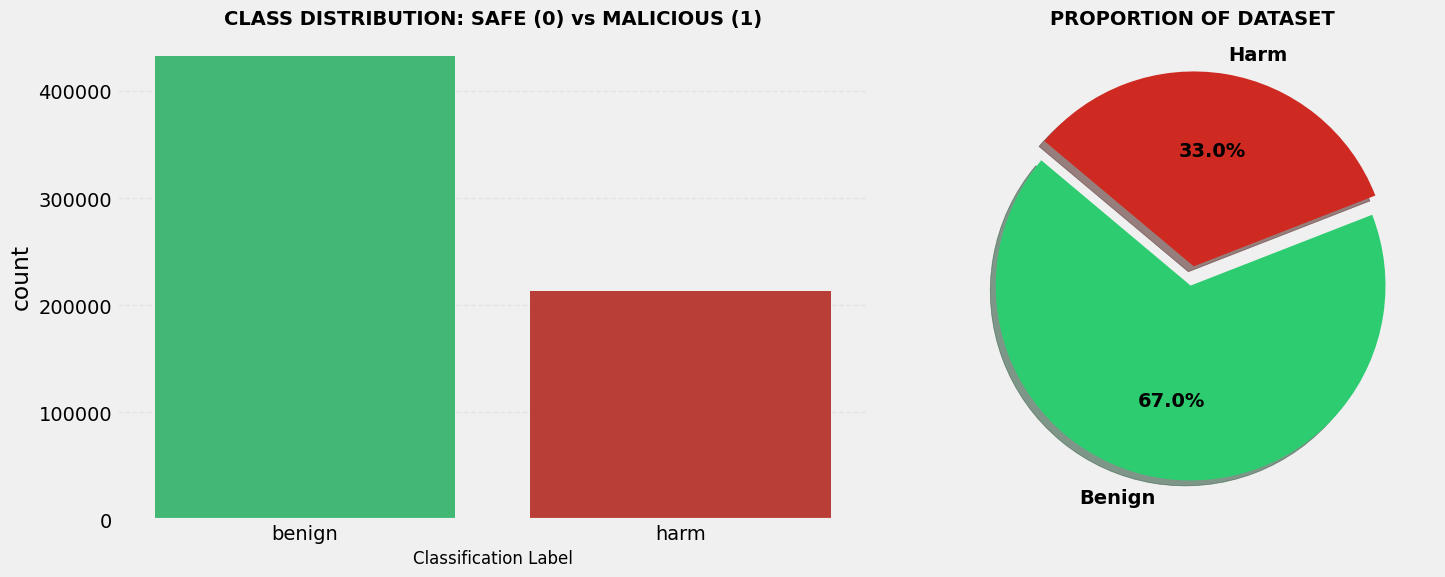

In [2]:
# 1. Define a fixed color map for consistency across all charts
# This ensures 'benign' is ALWAYS green and 'harm' is ALWAYS red
custom_colors = {
    'benign': '#2ecc71',  # Green (Safe)
    'harm': '#cf2a21'     # Red (Malicious)
}

# 2. Prepare the frequency data
type_counts = df['target'].value_counts().reset_index()
type_counts.columns = ['target', 'count']

# 3. Map colors strictly to the order of labels in type_counts for the Pie Chart
# This prevents the "color swap" bug
ordered_colors = [custom_colors[label] for label in type_counts['target']]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar Plot: Visualizing class frequency ---
# Passing the dictionary to 'palette' ensures Seaborn maps the colors correctly by name
sns.barplot(
    x='target', 
    y='count', 
    data=type_counts, 
    ax=ax[0], 
    palette=custom_colors, 
    hue='target', 
    legend=False
)
ax[0].set_title('CLASS DISTRIBUTION: SAFE (0) vs MALICIOUS (1)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Classification Label', fontsize=12)
ax[0].grid(axis='y', linestyle='--', alpha=0.3)

# --- Pie Chart: Visualizing dataset proportion ---
ax[1].pie(
    type_counts['count'], 
    labels=type_counts['target'].str.capitalize(), # Capitalize labels for a cleaner look
    autopct='%1.1f%%', 
    startangle=140,
    shadow=True, 
    explode=[0.05] * len(type_counts), # Slightly separate the slices
    colors=ordered_colors,
    textprops={'fontweight': 'bold'}
)
ax[1].set_title('PROPORTION OF DATASET', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Feature Ranking: Identifying the "Smoking Guns"

In URL analysis, we deal with dozens of extracted features. However, not all of them are effective at distinguishing a phishing link from a legitimate one. We use **Mutual Information (MI)** to quantify this relationship.

### 🧠 Understanding Mutual Information:
Unlike linear correlation, MI captures **any kind of statistical dependency**. It calculates how much information the presence (or value) of a feature contributes to reducing uncertainty about the `target` (Benign vs. Harm).

### 🛠️ Methodology:
1. **Numerical Selection:** We isolate numerical metrics (e.g., URL length, character counts, entropy) for the calculation.
2. **Target Encoding:** The categorical labels are converted into numerical codes to be compatible with the `mutual_info_classif` algorithm.
3. **Ranking:** Features are ranked by their **Information Gain**, helping us eliminate "noise" features that carry zero predictive weight.

C:\Users\vppho\AppData\Local\Temp\ipykernel_28624\1188735100.py:28: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vppho\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


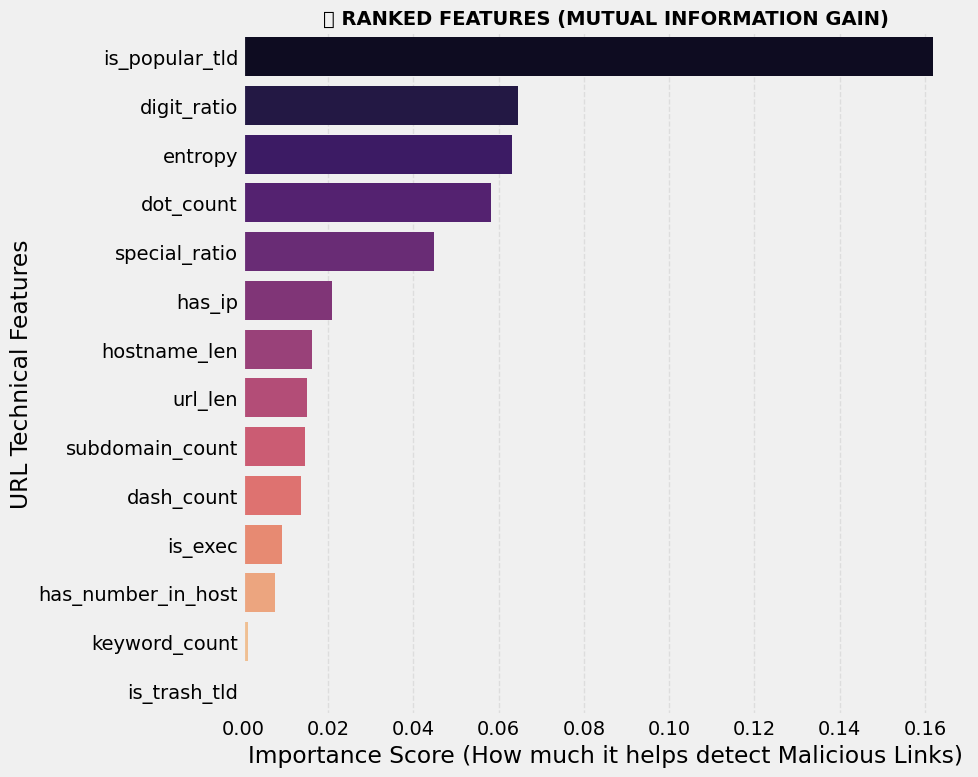

In [4]:
# 1. Prepare the data
# Select only numerical features for Mutual Information
X_eda = df.select_dtypes(include=['number'])

# Convert the 'target' column (categorical) to numerical codes for the algorithm
y_eda = df['target'].astype('category').cat.codes

# 2. Calculate Mutual Information
# This measures the dependency between features and the target (Benign vs Harm)
importances = mutual_info_classif(X_eda, y_eda, random_state=42)

# 3. Create a sorted result table
mi_df = pd.DataFrame({
    'Feature': X_eda.columns,
    'Importance_Score': importances
}).sort_values(by='Importance_Score', ascending=False)

# 4. Create an attractive plot
plt.figure(figsize=(10, 8))
# 'magma' or 'viridis' palettes provide a professional look for ranking
sns.barplot(x='Importance_Score', y='Feature', data=mi_df, palette='magma', hue='Feature', legend=False)

plt.title('🏆 RANKED FEATURES (MUTUAL INFORMATION GAIN)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (How much it helps detect Malicious Links)')
plt.ylabel('URL Technical Features')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Feature Polarization: Identifying Malicious Signatures

While the previous ranking showed us **which** features are important, this analysis reveals **how** they behave across different classes. By comparing the normalized means, we can create a "profile" for both safe and malicious URLs.

### 🧪 Methodology:
1. **Binary Mapping:** We consolidate all malicious sub-types (phishing, defacement, etc.) into a single `harm` class for a clear contrast against `benign` samples.
2. **Global Normalization:** Since URL features have vastly different scales (e.g., `url_length` can be in the hundreds, while `entropy` is usually < 8), we apply Min-Max normalization to ensure a fair comparison.
3. **Strength Calculation:** $$\text{Strength Score} = \text{Mean}_{\text{Benign}} - \text{Mean}_{\text{Harm}}$$
   * **Negative (<span style="color:#cf2a21">Red</span>):** Features that are more prevalent in **Malicious** URLs (e.g., suspicious character counts).
   * **Positive (<span style="color:#2ecc71">Green</span>):** Features typical of **Safe** URLs.

> **Why this matters:** This chart acts as a "Diagnostic Map." It tells us exactly which technical attributes a model will rely on to flag a link as dangerous.

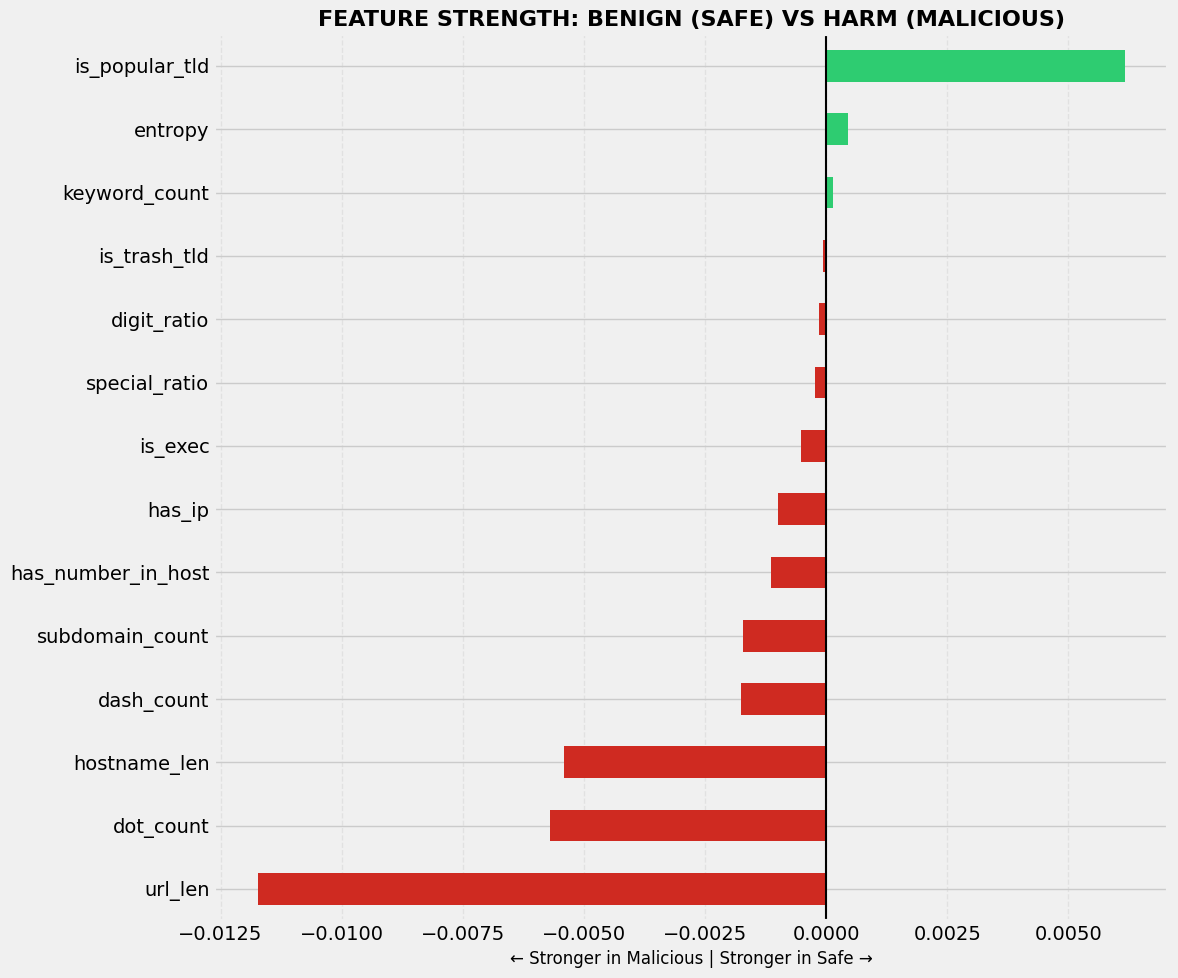

In [ ]:
# 1. Ensure binary labels: Map everything to 'benign' and 'harm'
df['target'] = df['target'].apply(lambda x: 'benign' if str(x).lower() == 'benign' else 'harm')

# 2. Calculate the average for each feature per class
# We only take numerical columns for the calculation
summary = df.groupby('target').mean(numeric_only=True)

# 3. Min-Max Normalization to ensure all features are on the same scale (0 to 1)
# This allows 'entropy' (0-8) and 'url_len' (0-200+) to be compared fairly
summary_norm = (summary - summary.min().min()) / (summary.max().max() - summary.min().min())

# 4. Calculate the Strength Score
# Positive score means the feature is stronger in Benign links
# Negative score means the feature is stronger in Harmful links
strength_score = (summary_norm.loc['benign'] - summary_norm.loc['harm']).sort_values()

# 5. Create the Visualization
plt.figure(figsize=(12, 10))
# Red for Harmful traits, Green for Benign traits
colors = ['#cf2a21' if x < 0 else '#2ecc71' for x in strength_score]
strength_score.plot(kind='barh', color=colors)

# 6. Formatting for a professional report
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
plt.title('FEATURE STRENGTH: BENIGN (SAFE) VS HARM (MALICIOUS)', fontsize=16, fontweight='bold')
plt.xlabel('← Stronger in Malicious | Stronger in Safe →', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Dynamic text annotations
plt.text(max(strength_score)*0.1, len(strength_score)-1, 'BENIGN INDICATORS', color='#2ecc71', fontweight='bold', fontsize=12)
plt.text(min(strength_score)*0.9, 0, 'MALICIOUS INDICATORS', color='#cf2a21', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()